In [22]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import KMeans


In [23]:
image_path="../output_videos/cropped_image.jpg"
image=cv2.imread(image_path)
image=cv2.cvtColor(image,cv2.COLOR_BGR2RGB)

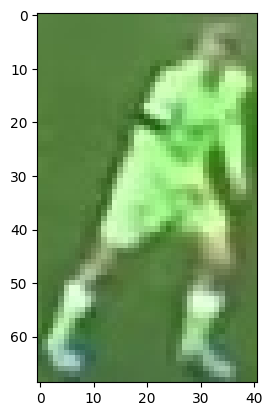

In [24]:
plt.imshow(image)


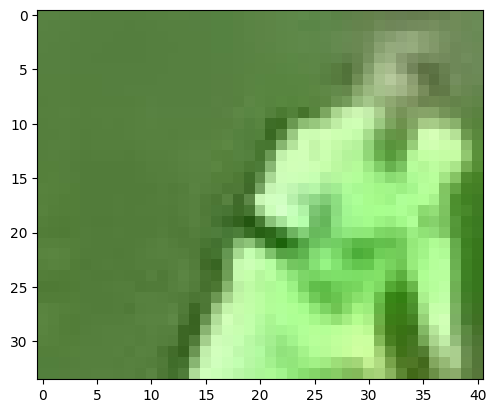

In [25]:
#take the top part of the image because shirt color is enough
top_half_image=image[0:int(image.shape[0]/2),:]
plt.imshow(top_half_image)

In [26]:
#reshape the image into a 2D array 
image_2d=top_half_image.reshape(-1,3)


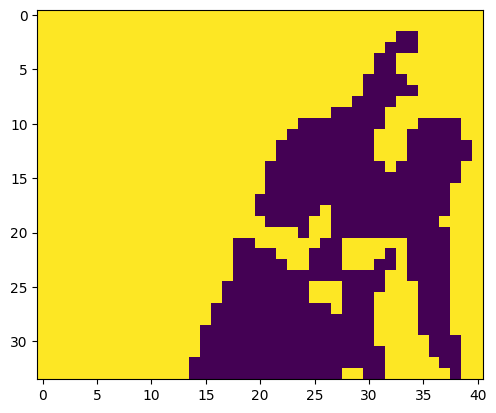

In [27]:
#cluster the image into two clusters and taking the average so that the shirt color will come
#perform kmeans clustering with 2 colors
kmeans=KMeans(n_clusters=2,random_state=0)
kmeans.fit(image_2d)

#get the cluster labels 
labels=kmeans.labels_

#reshape the labels into the original image shape 
clustered_image=labels.reshape(top_half_image.shape[0],top_half_image.shape[1])

#display the clustered image
plt.imshow(clustered_image)
plt.show()


In [28]:
corner_clusters=[clustered_image[0,0], clustered_image[0,-1], clustered_image[-1,0], clustered_image[-1,-1]]
non_player_cluster=max(set(corner_clusters), key=corner_clusters.count)
print(non_player_cluster)


1


In [29]:
player_cluster=1-non_player_cluster
print(player_cluster)

0


In [30]:
kmeans.cluster_centers_[player_cluster]

array([169.23341523, 233.10565111, 143.72235872])